# 📊 Customer Churn Analysis

## Project Overview

Customer churn is an important business problem for subscription-based companies. This project analyzes customer data from a telecommunications company to identify the major factors associated with customer churn.

The analysis focuses on customer demographics, services, contracts, payment methods, tenure, and monthly charges to understand which customer groups are more likely to leave.

## Objectives

- Analyze the overall customer churn rate.
- Identify customer segments with high churn.
- Study the impact of contract type, internet service, payment method, tenure, and monthly charges.
- Examine whether services such as Tech Support, Online Security, and Device Protection are associated with lower churn.
- Generate actionable business insights that could help improve customer retention.

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Dataset

The dataset contains *7,043 customers and 21 columns*, including customer demographics, subscribed services, account information, charges, and churn status.

## 1. Import Libraries

In [70]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.5
NumPy version: 2.5.2


## 2. Load Dataset

In [71]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Understanding

In [72]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [73]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 4. Data Cleaning

Before performing exploratory analysis, the dataset was cleaned to ensure data quality and consistency.

The following steps were performed:
- Converted TotalCharges to a numeric data type.
- Checked for missing values.
- Handled missing values where necessary.
- Checked for duplicate records.
- Verified the dataset after cleaning.

In [75]:
df[df["TotalCharges"].str.strip() == ""]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [76]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

In [77]:
df.duplicated().sum()

df["customerID"].duplicated().sum()

np.int64(0)

In [78]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())
    


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

C:\Users\Amrit\AppData\Local\Temp\ipykernel_15700\4277059227.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand customer churn patterns and identify the factors most strongly associated with customer attrition.

The analysis focuses on:

- Overall churn distribution
- Customer tenure and monthly charges
- Contract type
- Internet service
- Payment method
- Senior citizen status
- Partner and dependent status
- Tech support and online security
- Paperless billing
- Device protection

### 5.1 Overall Churn Distribution

In [79]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [80]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [81]:
import matplotlib.pyplot as plt

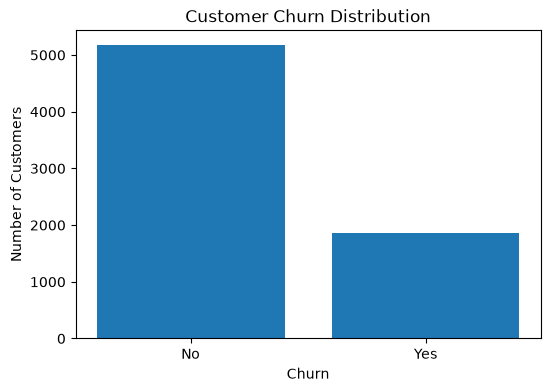

In [82]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### 5.2 Contract & Payment Analysis

This section analyzes how contract type, payment method, and billing preferences are associated with customer churn.

In [83]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


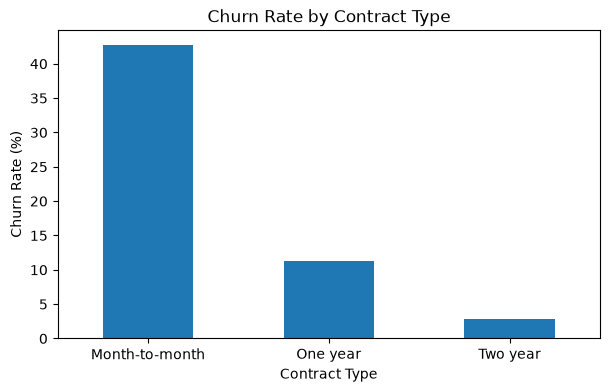

In [84]:
contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [85]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

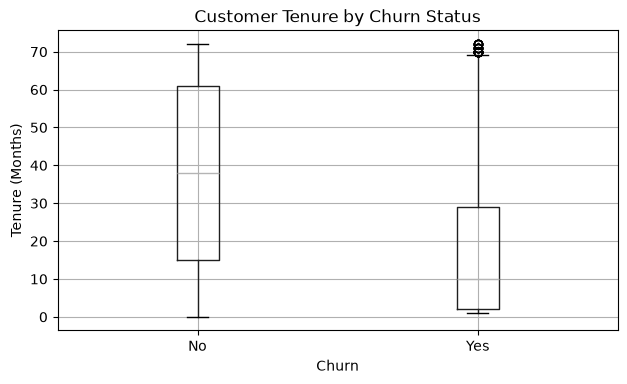

In [86]:
df.boxplot(column="tenure", by="Churn", figsize=(7, 4))

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [87]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

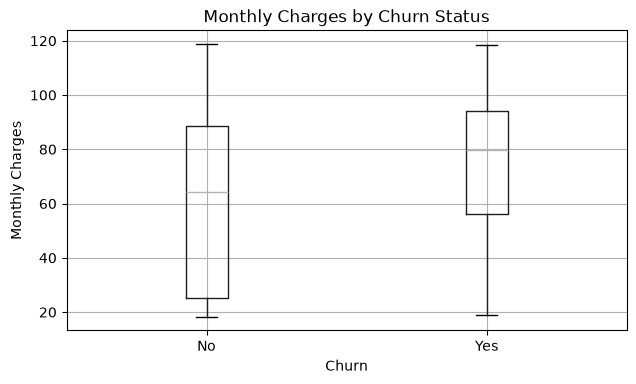

In [88]:
df.boxplot(column="MonthlyCharges", by="Churn", figsize=(7, 4))

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### 5.3 Internet & Support Services

This section analyzes how internet service type and customer support-related services influence churn.

The analysis includes:
- Internet Service
- Tech Support
- Online Security
- Device Protection

In [89]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


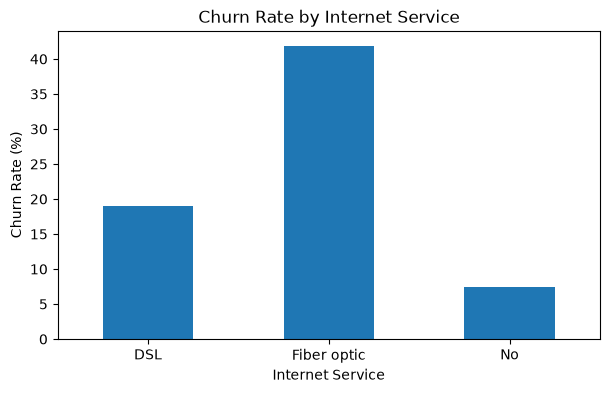

In [90]:
internet_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [91]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


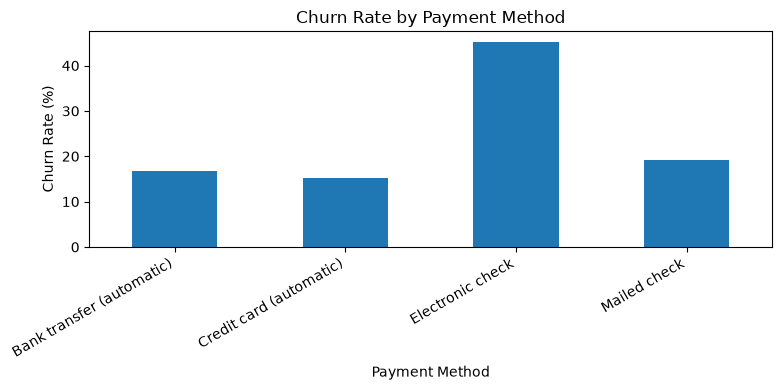

In [92]:
payment_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5.4 Customer Demographics

This section examines how customer demographic and household characteristics are associated with churn.

The analysis includes:
- Senior Citizen Status
- Partner Status
- Dependents

In [93]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


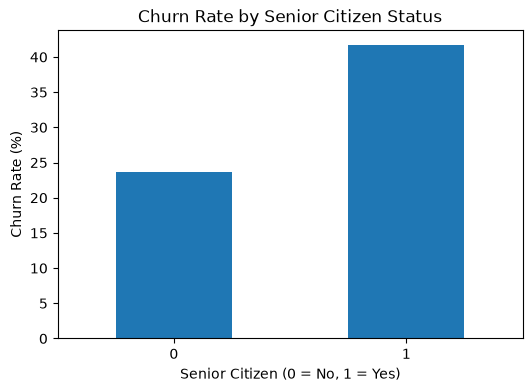

In [94]:
senior_churn["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [95]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


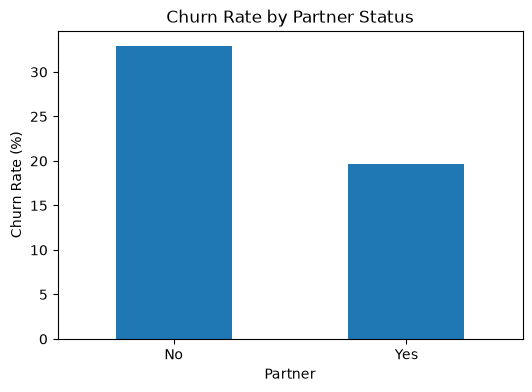

In [96]:
partner_churn["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [97]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


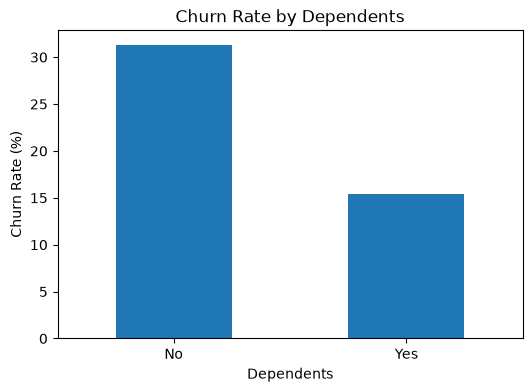

In [98]:
dependents_churn["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [99]:
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


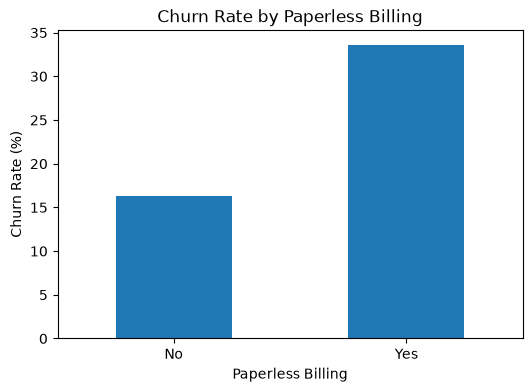

In [100]:
paperless_churn["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [101]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


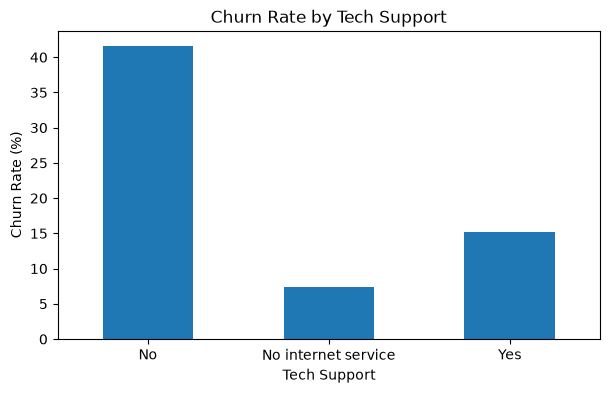

In [102]:
techsupport_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [103]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


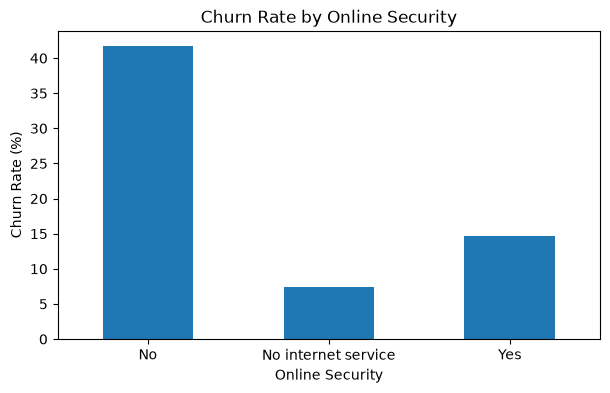

In [104]:
security_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [105]:

device_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_churn

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


# 6. Key Business Insights

The exploratory analysis revealed several important customer churn patterns:

- The overall customer churn rate is approximately *26.5%*, meaning roughly one in four customers leave the company.
- *Month-to-month contract customers* have the highest churn rate at approximately *42.7%*, significantly higher than customers on one-year or two-year contracts.
- Customers using *fiber optic internet service* show considerably higher churn than DSL customers.
- Customers paying through *electronic check* have the highest churn rate among payment methods.
- Customers without *Tech Support* show substantially higher churn than customers who subscribe to Tech Support.
- Customers without *Online Security* also have a considerably higher churn rate.
- *Paperless billing* customers show higher churn than customers using non-paperless billing.
- *Senior citizens* have a higher churn rate than non-senior customers.
- Customers without a *partner or dependents* generally demonstrate higher churn.
- Customers without *Device Protection* show higher churn than customers who subscribe to the service.

### High-Risk Customer Profile

Based on the analysis, customers with several of the following characteristics represent a higher-risk churn segment:

*Month-to-month contract + Fiber optic service + Electronic check payment + No Tech Support + No Online Security + Paperless Billing + Short customer tenure*

## 7. Business Recommendations

Based on the churn analysis, the following actions could help improve customer retention:

1. *Encourage long-term contracts*  
   Offer discounts, loyalty rewards, or additional benefits to encourage month-to-month customers to move to one-year or two-year contracts.

2. *Target new customers early*  
   Customers with shorter tenure show higher churn. Introduce onboarding programs, early-stage engagement campaigns, and retention offers during the first few months.

3. *Investigate fiber optic customer experience*  
   Fiber optic customers show relatively high churn. The company should investigate service quality, pricing, reliability, and customer satisfaction within this segment.

4. *Promote support and security services*  
   Customers without Tech Support and Online Security show higher churn. Bundled or discounted support packages could improve customer retention.

5. *Review electronic check payments*  
   Customers using electronic checks have a higher churn rate. Incentives could be offered for switching to automatic payment methods.

6. *Develop targeted retention campaigns*  
   High-risk customers can be identified using combinations of contract type, tenure, monthly charges, internet service, payment method, and support services.

## 8. Conclusion

This project analyzed customer churn patterns using Python and exploratory data analysis.

The analysis shows that churn is strongly associated with factors such as contract type, customer tenure, monthly charges, internet service, payment method, and access to support services.

Month-to-month customers, customers with shorter tenure, fiber optic users, electronic check users, and customers without services such as Tech Support and Online Security represent important high-risk segments.

By identifying these customer groups early and implementing targeted retention strategies, the company can potentially reduce customer churn, improve customer satisfaction, and increase customer lifetime value.

### Project Outcome

This analysis demonstrates how customer data can be transformed into actionable business insights that support data-driven customer retention decisions.